In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

In [7]:
cols = ["fLength","fWidth","fSize","fConc","fConcl","FfAsym","fM3Long","fM3Trans","fAlpha","fdist","Class"]
df = pd.read_csv("magic04.data",names=cols)
df.head()

,fLength,fWidth,fSize,fConc,fConcl,FfAsym,fM3Long,fM3Trans,fAlpha,fdist,Class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [8]:
df["Class"] = (df["Class"] == "g").astype(int)

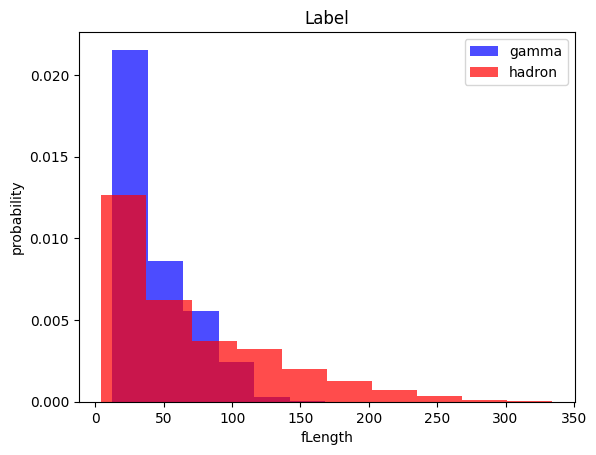

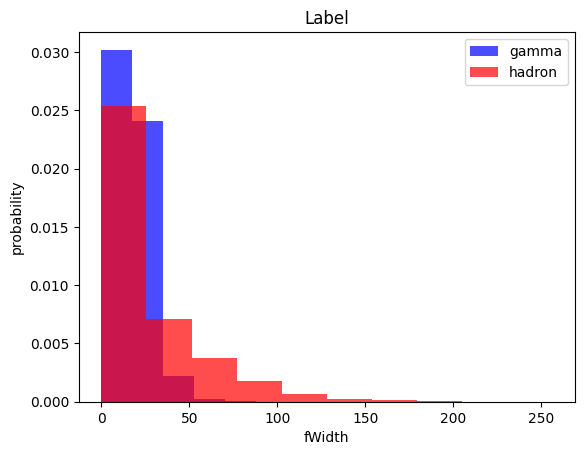

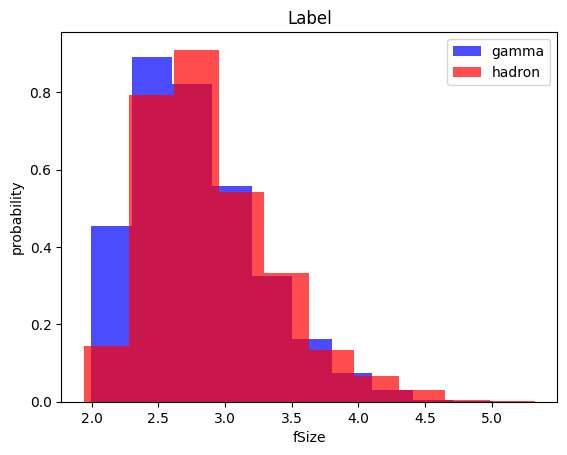

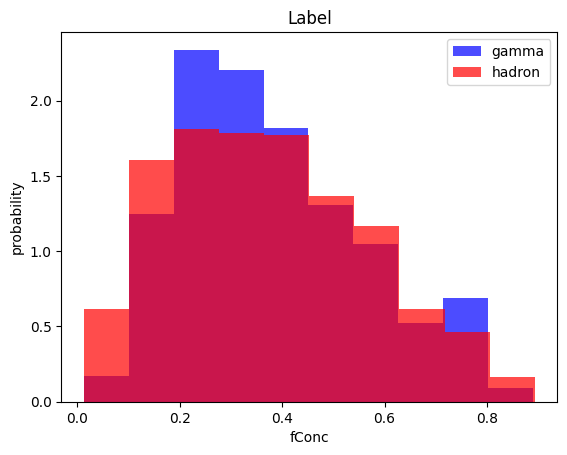

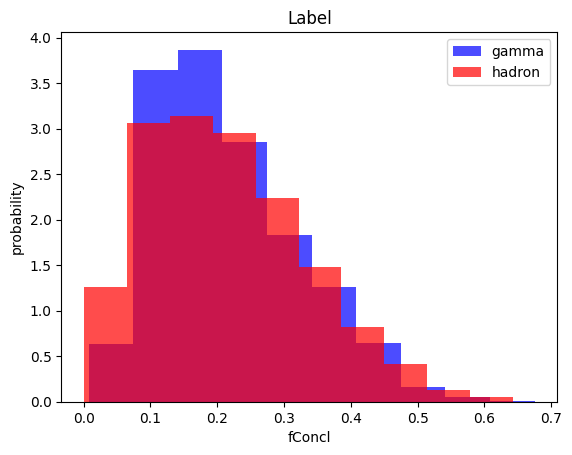

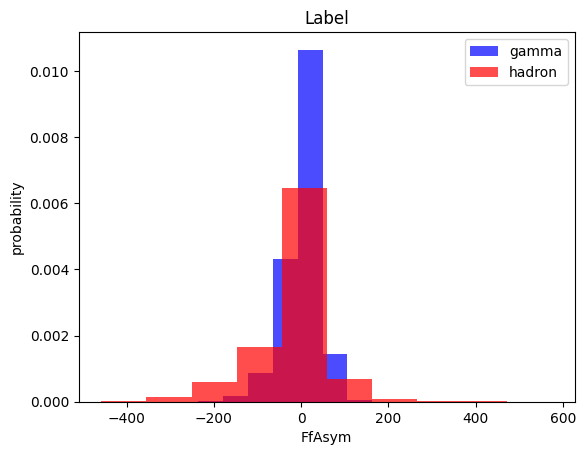

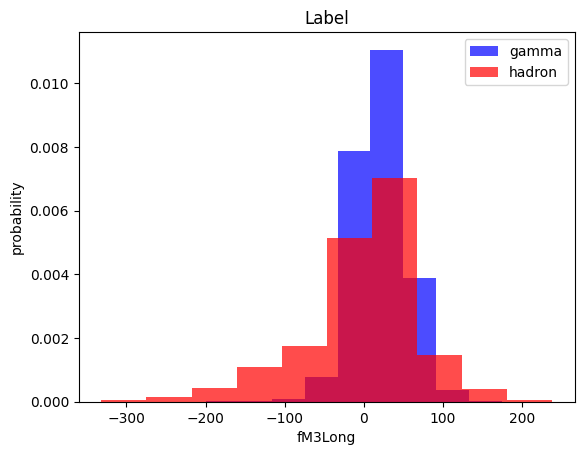

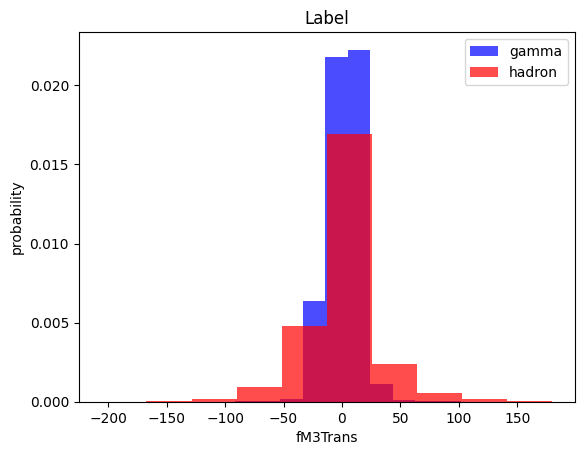

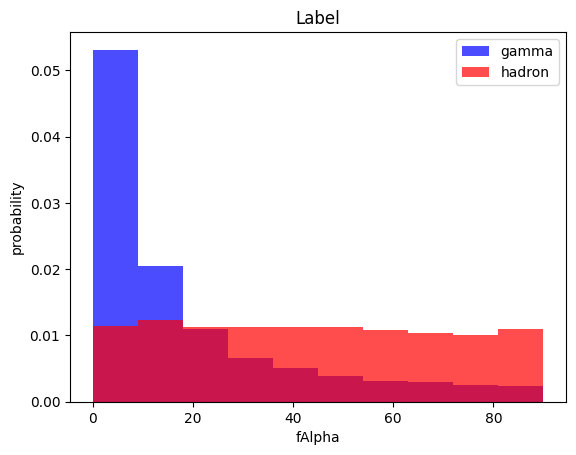

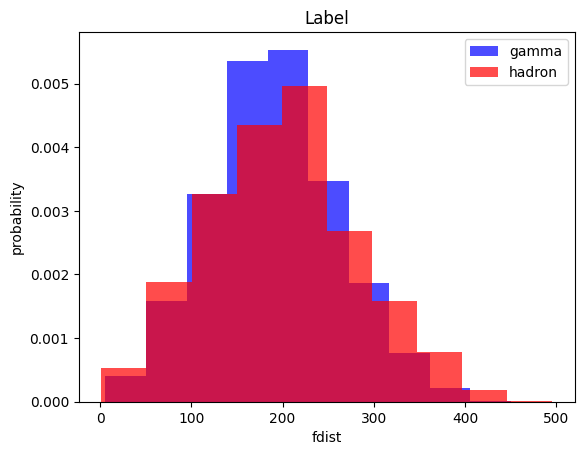

In [9]:
for label in cols[:-1]:
  plt.hist(df[df["Class"] == 1][label],alpha = 0.7 , label = "gamma", color = "blue",density = True)
  plt.hist(df[df["Class"] == 0][label],alpha = 0.7 , label = "hadron", color = "red",density= True)
  plt.title("Label")
  plt.xlabel(label)
  plt.ylabel("probability")
  plt.legend()
  plt.show()


# train, validate, teat data set

In [10]:
train , valid , test = np.split(df.sample(frac=1), [int(0.6*len(df)),int(0.8*len(df))])

c:\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [11]:
def scale_Dataset(dataframe,oversample):
  x = dataframe[dataframe.columns[:-1]].values
  y = dataframe[dataframe.columns[-1]].values

  scaler = StandardScaler()
  x = scaler.fit_transform(x)

  if oversample:
    ros = RandomOverSampler()
    x , y = ros.fit_resample(x,y)


  data = np.hstack((x,np.reshape(y, (-1,1))))

  return data , x, y

In [12]:
train ,x_train,y_train = scale_Dataset(train,oversample = True)
valid ,x_valid,y_valid = scale_Dataset(valid,oversample = False)
test ,x_test,y_test = scale_Dataset(test,oversample = False)

#KNN

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [14]:
knn_model = KNeighborsClassifier(n_neighbors= 5)
knn_model.fit(x_train,y_train)

KNeighborsClassifier()

In [15]:
y_pred = knn_model.predict(x_test)

In [16]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.74      0.73      0.73      1346
           1       0.85      0.86      0.86      2458

    accuracy                           0.81      3804
   macro avg       0.80      0.79      0.80      3804
weighted avg       0.81      0.81      0.81      3804



# Naive Bayes

In [17]:
from sklearn.naive_bayes import GaussianNB


In [18]:
NB_model = GaussianNB()
NB_model = NB_model.fit(x_train,y_train)

In [19]:
y_pred = NB_model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.67      0.40      0.50      1346
           1       0.73      0.89      0.80      2458

    accuracy                           0.72      3804
   macro avg       0.70      0.65      0.65      3804
weighted avg       0.71      0.72      0.70      3804



# Logistic reggression 

In [20]:
from sklearn.linear_model import LogisticRegression

In [21]:
lg_model = LogisticRegression()
lg_model = lg_model.fit(x_train,y_train)

In [22]:
y_pred = lg_model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.68      0.72      0.70      1346
           1       0.84      0.82      0.83      2458

    accuracy                           0.78      3804
   macro avg       0.76      0.77      0.76      3804
weighted avg       0.79      0.78      0.78      3804



# SVM MOdel 

In [23]:
from sklearn.svm import SVC

In [24]:
svm_model = SVC()
svm_model = svm_model.fit(x_train, y_train)

In [25]:
y_pred = svm_model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1346
           1       0.89      0.90      0.90      2458

    accuracy                           0.86      3804
   macro avg       0.85      0.85      0.85      3804
weighted avg       0.86      0.86      0.86      3804



In [26]:
import tensorflow as tf 

In [36]:
def plot_history (history) :
    fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10,4))
    ax1.plot(history.history['loss' ], label=' loss')
    ax1.plot(history.history['val_loss' ], label='val loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Binary crossentropy')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot (history.history[ 'accuracy' ], label='accuracy' )
    ax2.plot(history.history[ 'val_accuracy' ], label='val_accuracy' )
    ax2.set_xlabel ('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)



    plt.show()

In [33]:
def train_model(x_train,y_train, num_node, dropout_prob, lr,batch_size,epochs):
    nn_model = tf.keras.Sequential([
        tf.keras.layers.Dense(num_node, activation= 'relu', input_shape = (10,)),
        tf.keras.layers.Dropout(dropout_prob),
        tf.keras.layers.Dense(num_node,activation='relu'),
        tf.keras.layers.Dropout(dropout_prob),
        tf.keras.layers.Dense(1, activation = 'sigmoid')
    ])
    nn_model.compile(optimizer= tf.keras.optimizers.Adam(0.001), loss='binary_crossentropy',metrics=['accuracy'])
    history = nn_model.fit(
    x_train,y_train, epochs = epochs,batch_size = batch_size, validation_split = 0.2, verbose = 0
    )

    return nn_model, history


16 nodes ,dropout 0, lr 0.01,batch_size 32


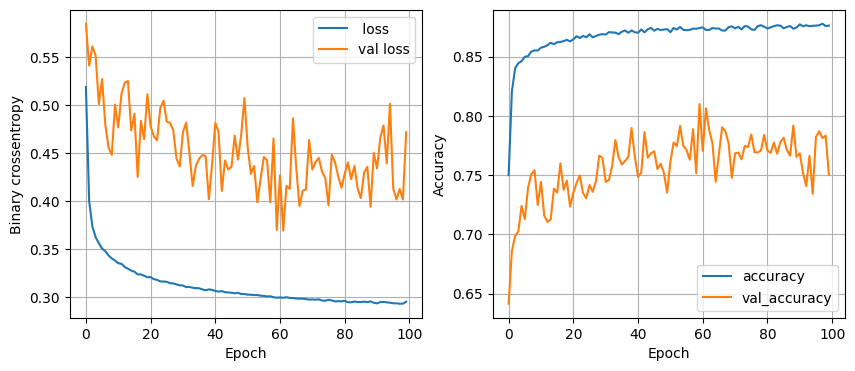

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step - accuracy: 0.8741 - loss: 0.3014
16 nodes ,dropout 0, lr 0.01,batch_size 64


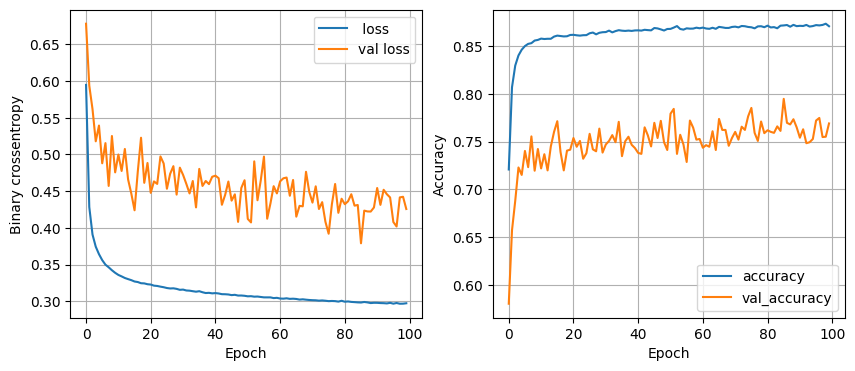

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8738 - loss: 0.3077
16 nodes ,dropout 0, lr 0.01,batch_size 128


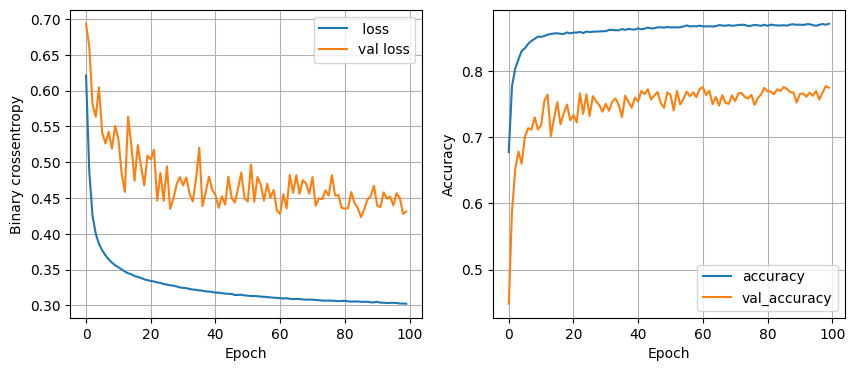

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8736 - loss: 0.3132
16 nodes ,dropout 0, lr 0.005,batch_size 32


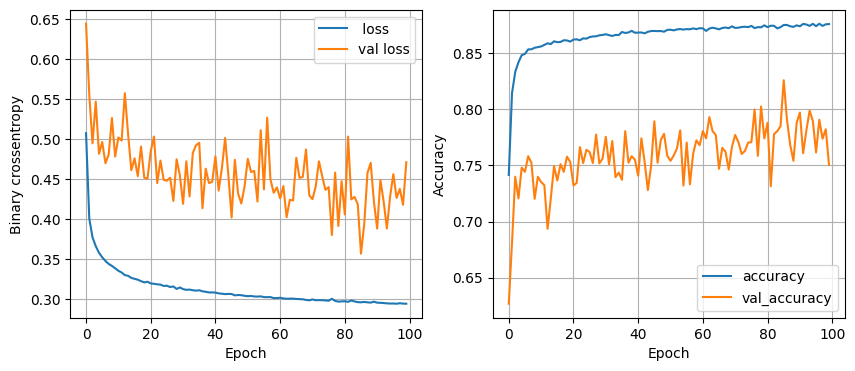

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8801 - loss: 0.2986
16 nodes ,dropout 0, lr 0.005,batch_size 64


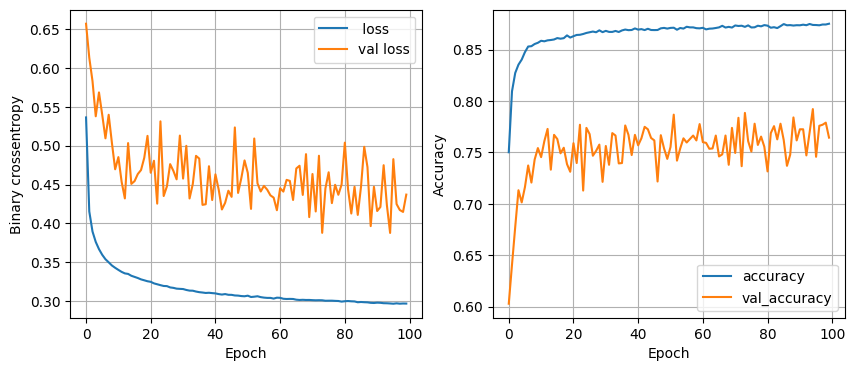

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 810us/step - accuracy: 0.8793 - loss: 0.3071
16 nodes ,dropout 0, lr 0.005,batch_size 128


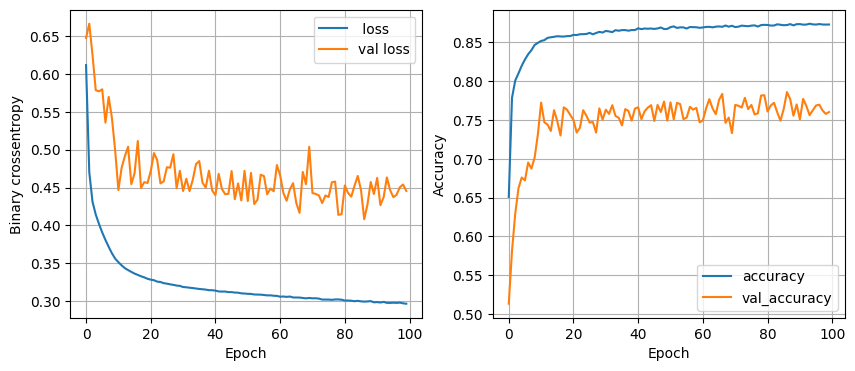

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8759 - loss: 0.3120  
16 nodes ,dropout 0, lr 0.001,batch_size 32


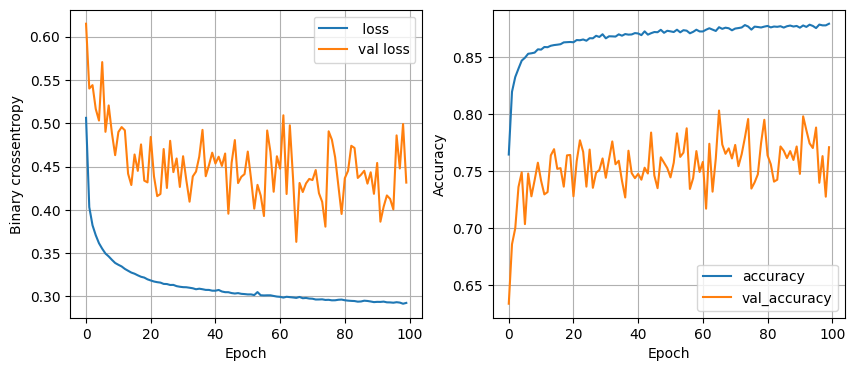

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8762 - loss: 0.3087
16 nodes ,dropout 0, lr 0.001,batch_size 64


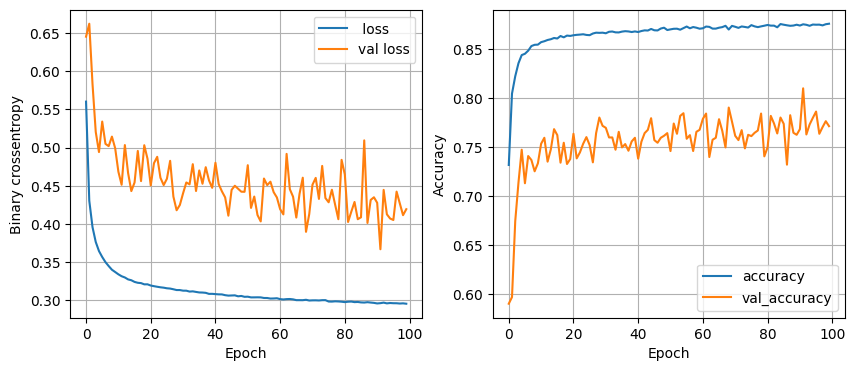

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 859us/step - accuracy: 0.8809 - loss: 0.3097
16 nodes ,dropout 0, lr 0.001,batch_size 128


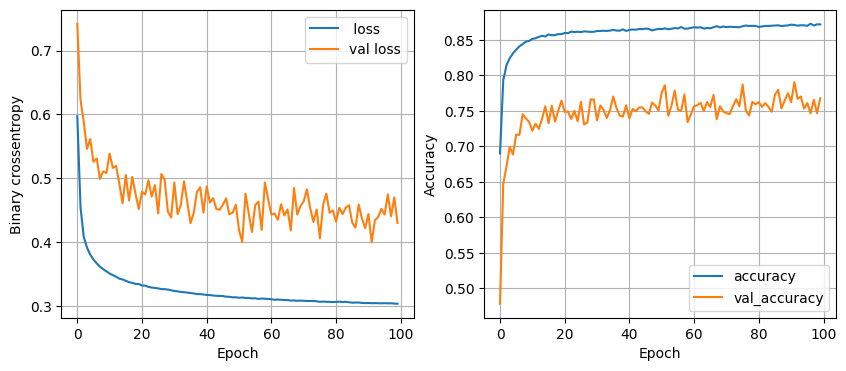

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8730 - loss: 0.3108  
16 nodes ,dropout 0.2, lr 0.01,batch_size 32


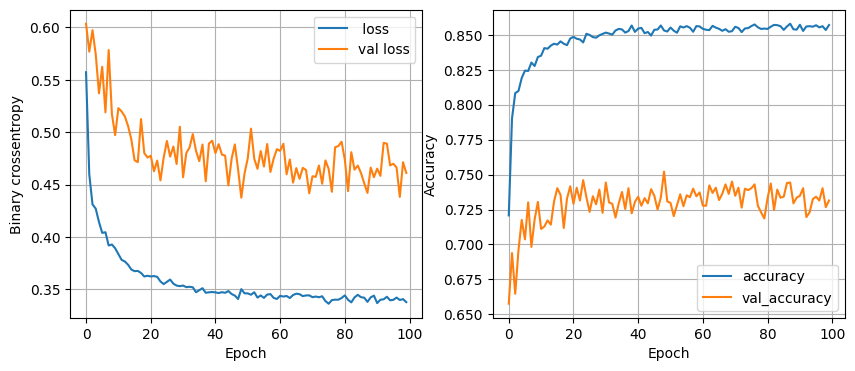

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 997us/step - accuracy: 0.8728 - loss: 0.3152
16 nodes ,dropout 0.2, lr 0.01,batch_size 64


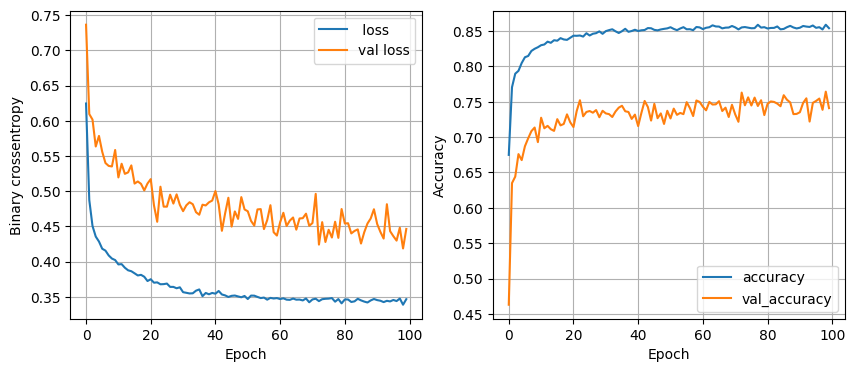

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8686 - loss: 0.3182
16 nodes ,dropout 0.2, lr 0.01,batch_size 128


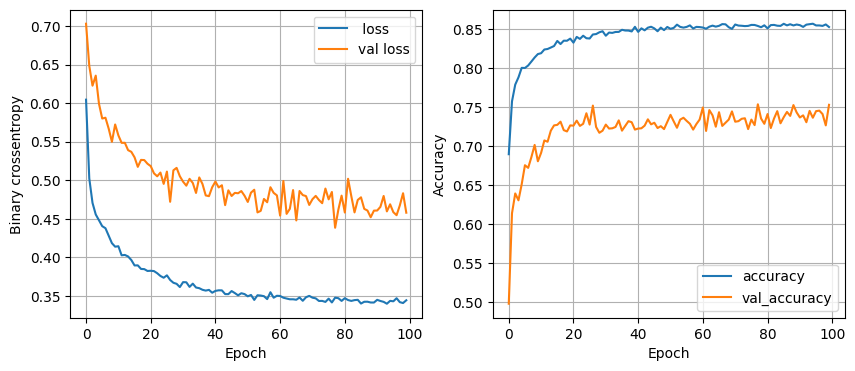

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8659 - loss: 0.3141  
16 nodes ,dropout 0.2, lr 0.005,batch_size 32


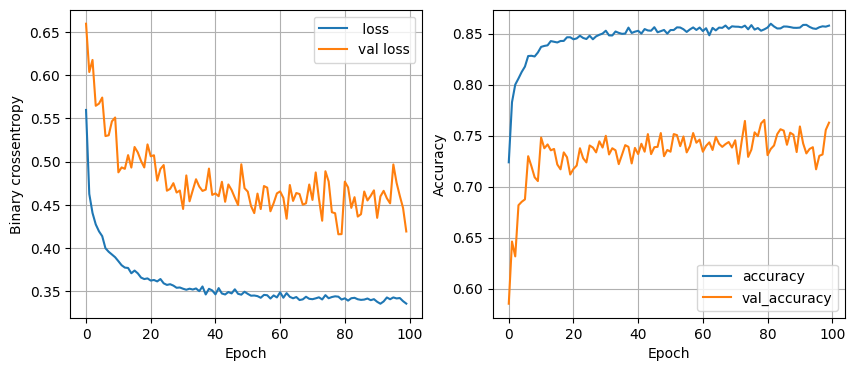

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8683 - loss: 0.3179
16 nodes ,dropout 0.2, lr 0.005,batch_size 64


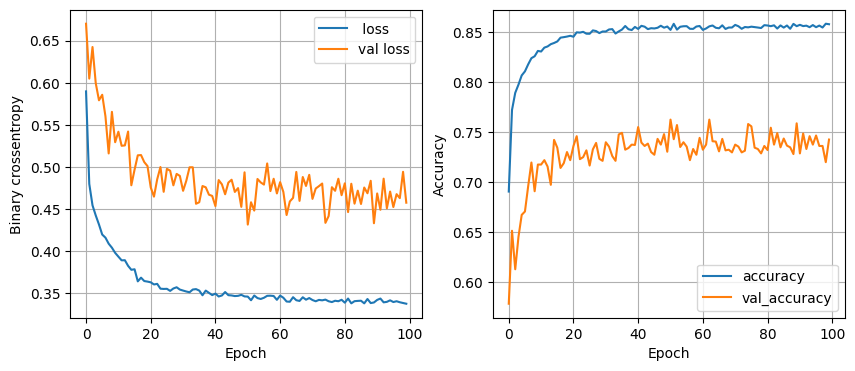

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8709 - loss: 0.3140
16 nodes ,dropout 0.2, lr 0.005,batch_size 128


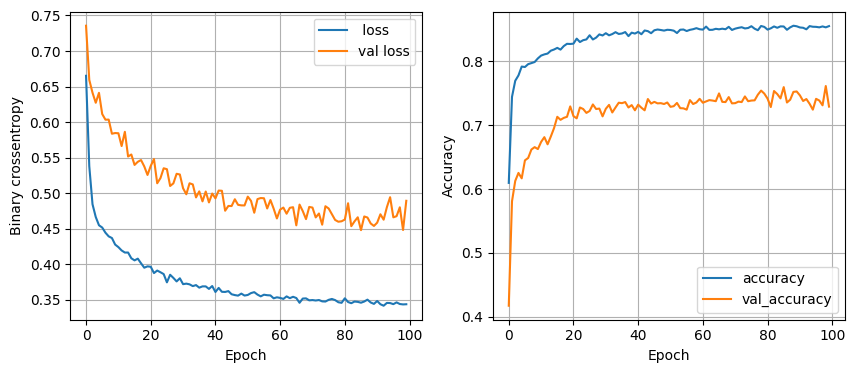

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 955us/step - accuracy: 0.8675 - loss: 0.3174
16 nodes ,dropout 0.2, lr 0.001,batch_size 32


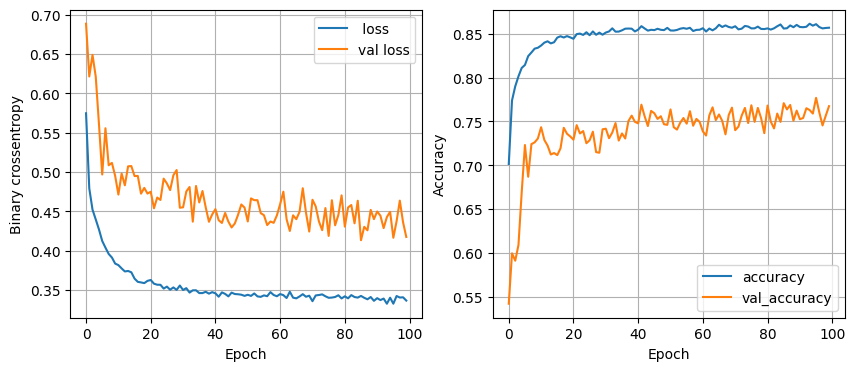

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step - accuracy: 0.8707 - loss: 0.3158
16 nodes ,dropout 0.2, lr 0.001,batch_size 64


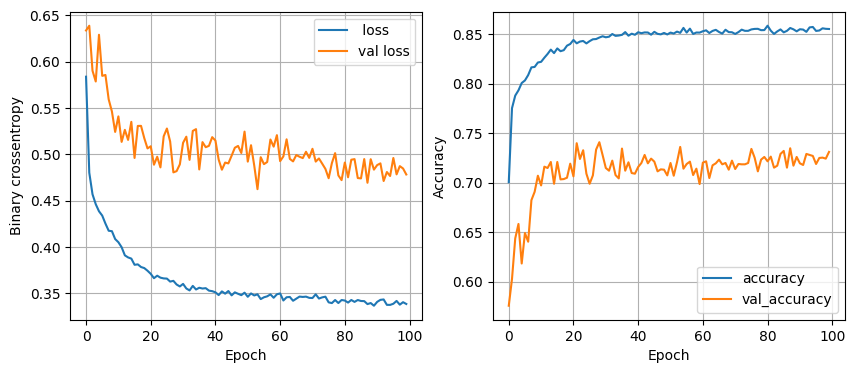

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 915us/step - accuracy: 0.8741 - loss: 0.3091
16 nodes ,dropout 0.2, lr 0.001,batch_size 128


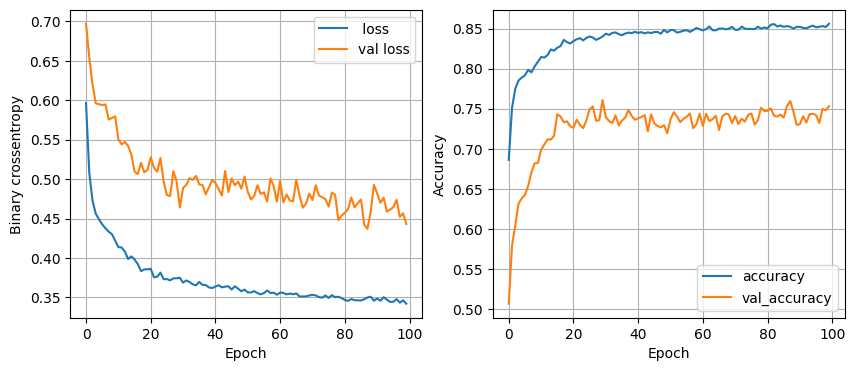

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 922us/step - accuracy: 0.8675 - loss: 0.3189
32 nodes ,dropout 0, lr 0.01,batch_size 32


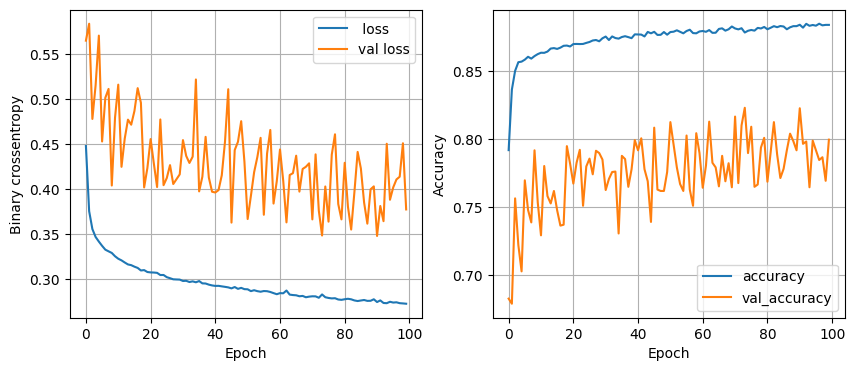

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8772 - loss: 0.3055
32 nodes ,dropout 0, lr 0.01,batch_size 64


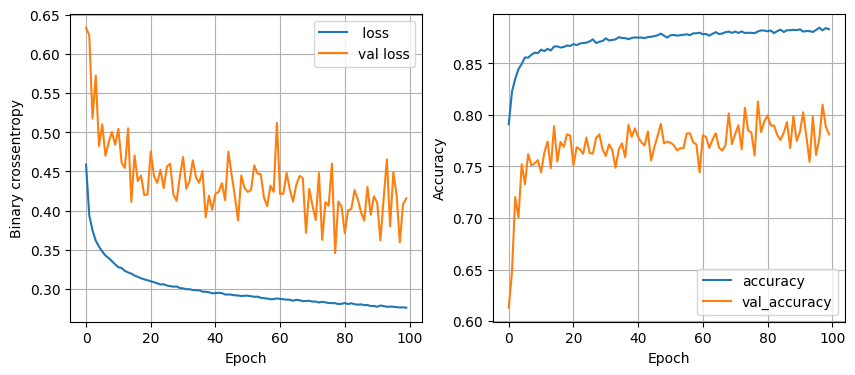

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8733 - loss: 0.3144
32 nodes ,dropout 0, lr 0.01,batch_size 128


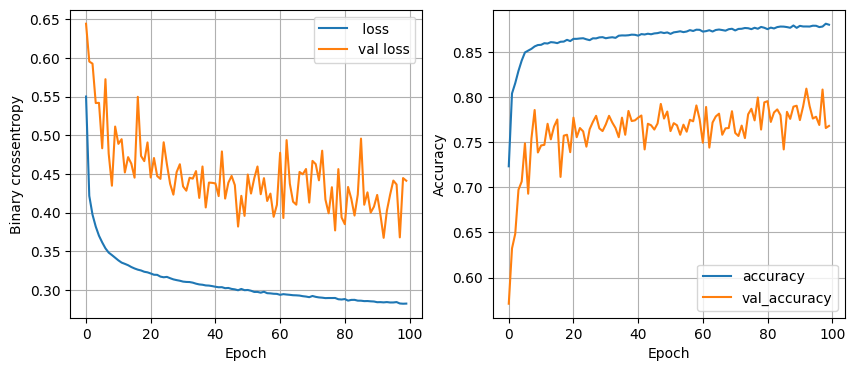

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8767 - loss: 0.3073
32 nodes ,dropout 0, lr 0.005,batch_size 32


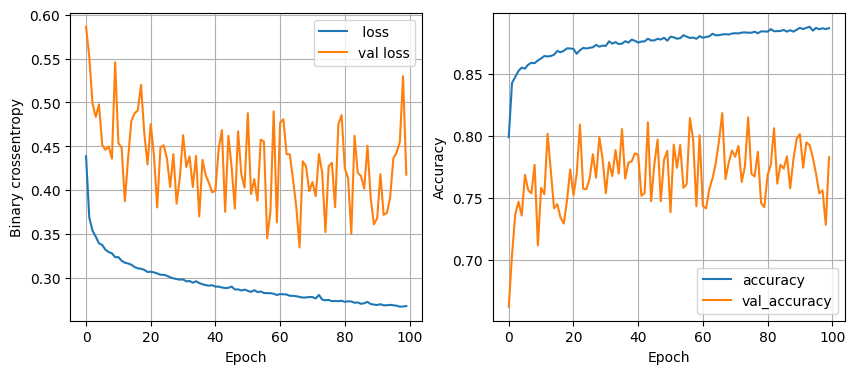

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 867us/step - accuracy: 0.8712 - loss: 0.3159
32 nodes ,dropout 0, lr 0.005,batch_size 64


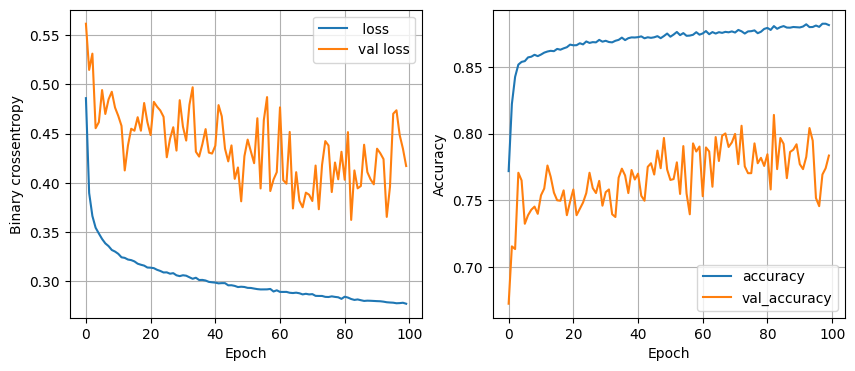

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8788 - loss: 0.3060
32 nodes ,dropout 0, lr 0.005,batch_size 128


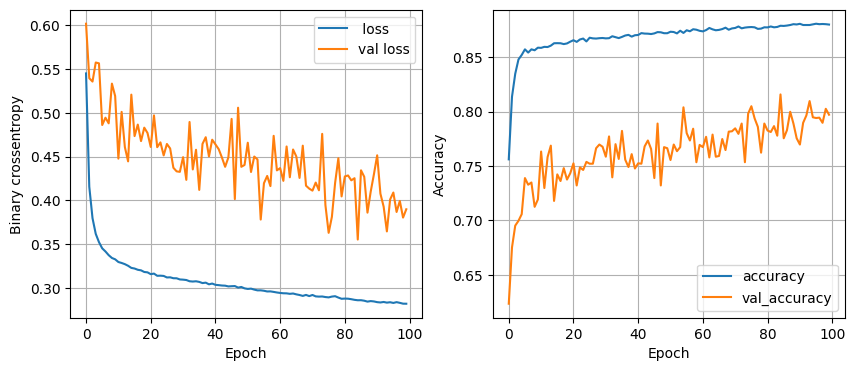

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 865us/step - accuracy: 0.8746 - loss: 0.3079
32 nodes ,dropout 0, lr 0.001,batch_size 32


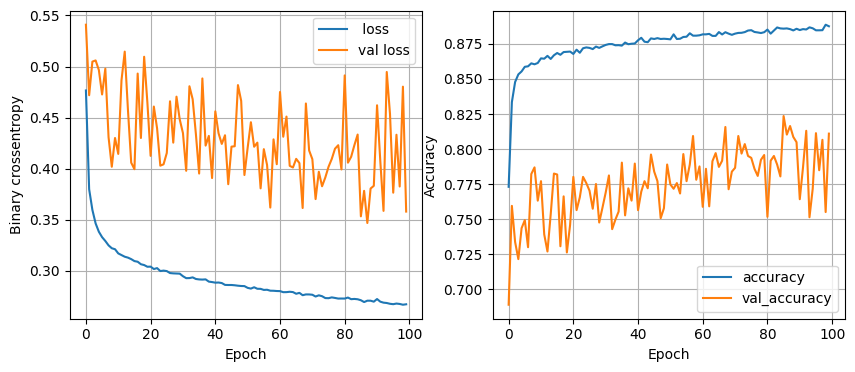

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 871us/step - accuracy: 0.8717 - loss: 0.3283
32 nodes ,dropout 0, lr 0.001,batch_size 64


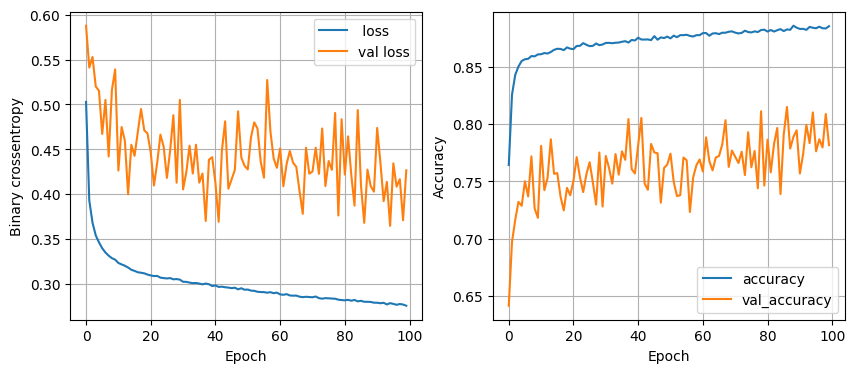

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8749 - loss: 0.3093
32 nodes ,dropout 0, lr 0.001,batch_size 128


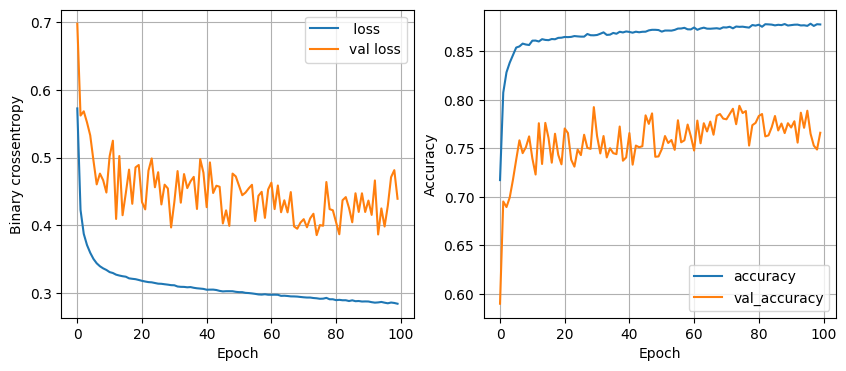

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8793 - loss: 0.3034
32 nodes ,dropout 0.2, lr 0.01,batch_size 32


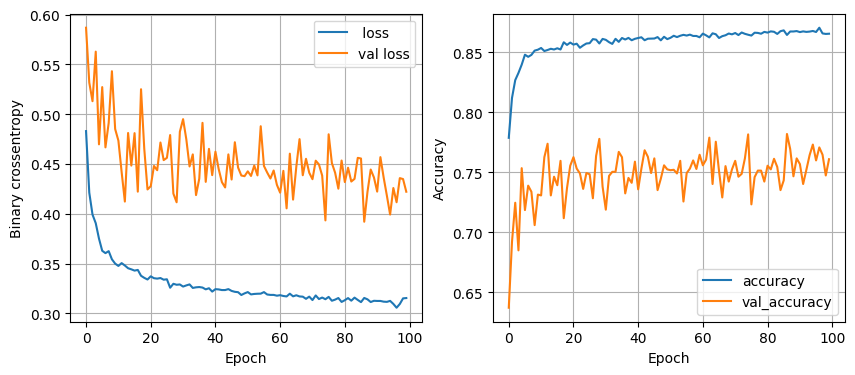

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8791 - loss: 0.3009  
32 nodes ,dropout 0.2, lr 0.01,batch_size 64


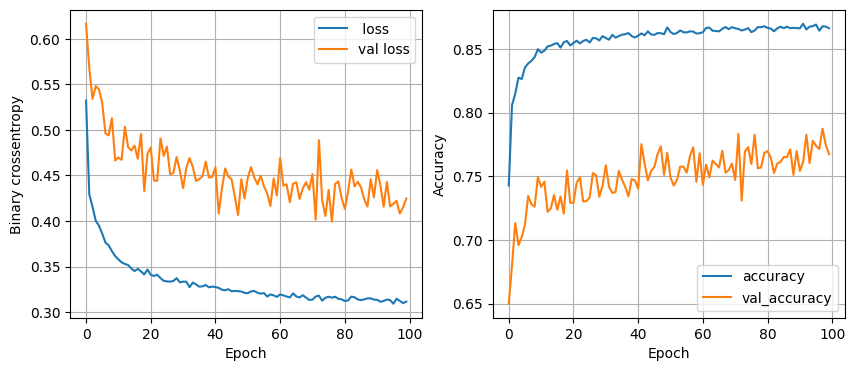

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8764 - loss: 0.2994  
32 nodes ,dropout 0.2, lr 0.01,batch_size 128


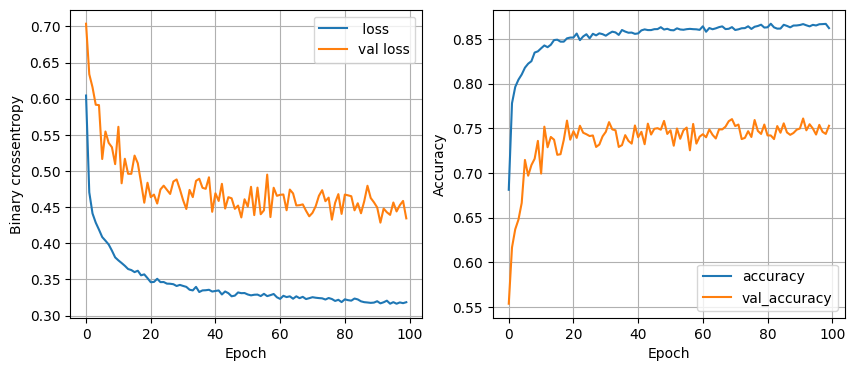

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8759 - loss: 0.3050
32 nodes ,dropout 0.2, lr 0.005,batch_size 32


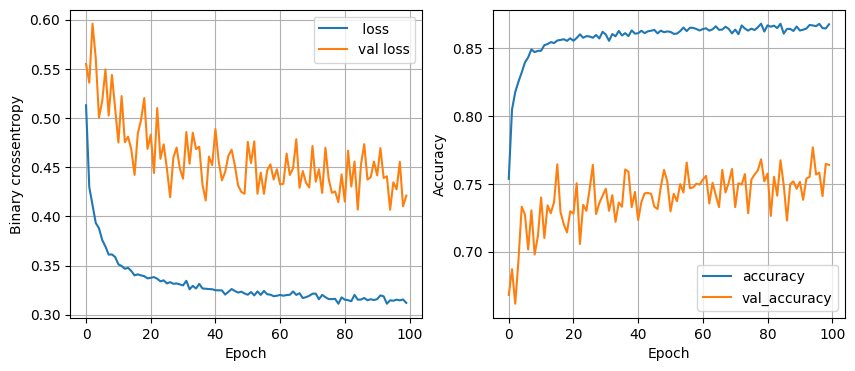

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 871us/step - accuracy: 0.8757 - loss: 0.3051
32 nodes ,dropout 0.2, lr 0.005,batch_size 64


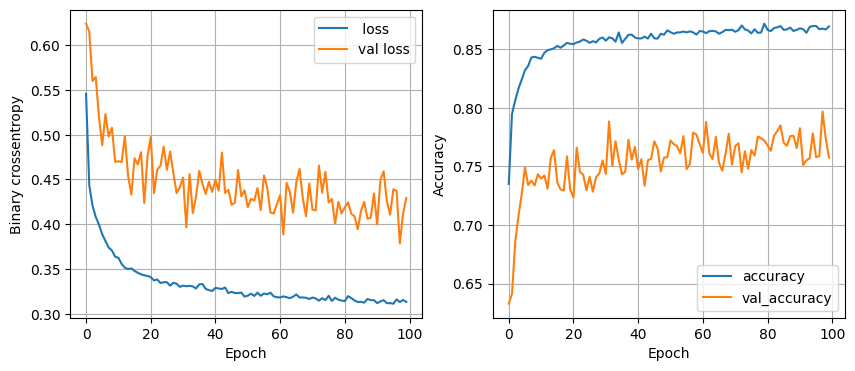

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 931us/step - accuracy: 0.8757 - loss: 0.2983
32 nodes ,dropout 0.2, lr 0.005,batch_size 128


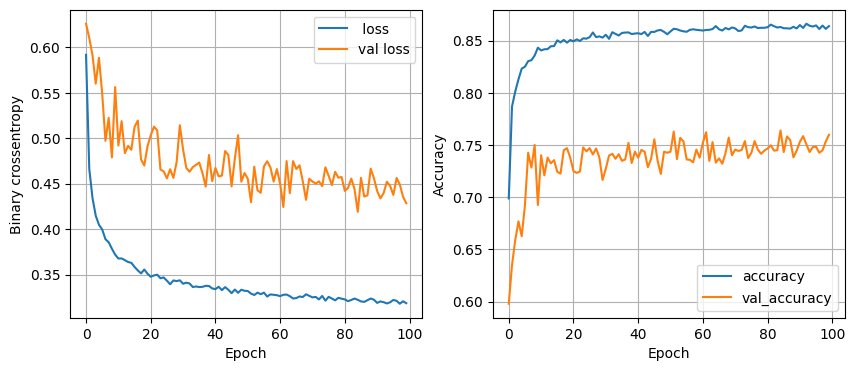

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 919us/step - accuracy: 0.8751 - loss: 0.3027
32 nodes ,dropout 0.2, lr 0.001,batch_size 32


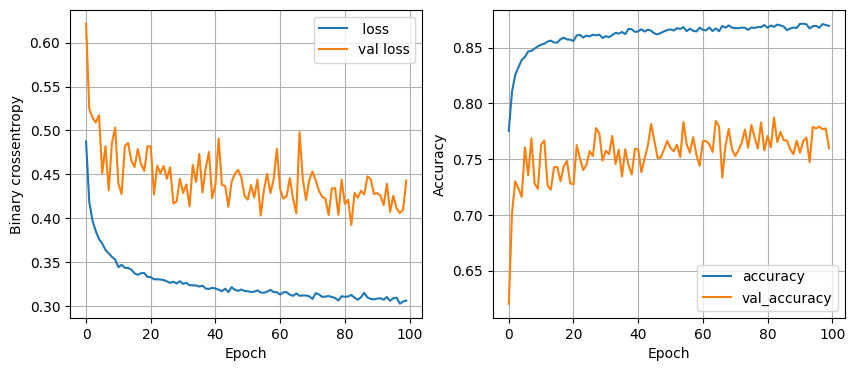

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 809us/step - accuracy: 0.8770 - loss: 0.2986
32 nodes ,dropout 0.2, lr 0.001,batch_size 64


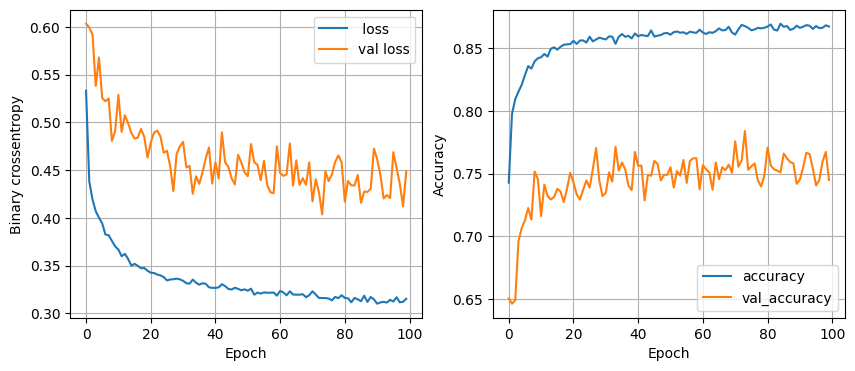

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8780 - loss: 0.2971  
32 nodes ,dropout 0.2, lr 0.001,batch_size 128


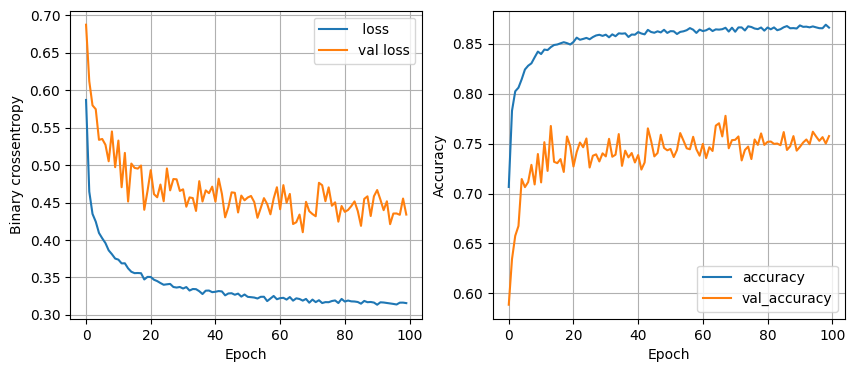

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 835us/step - accuracy: 0.8788 - loss: 0.2984
64 nodes ,dropout 0, lr 0.01,batch_size 32


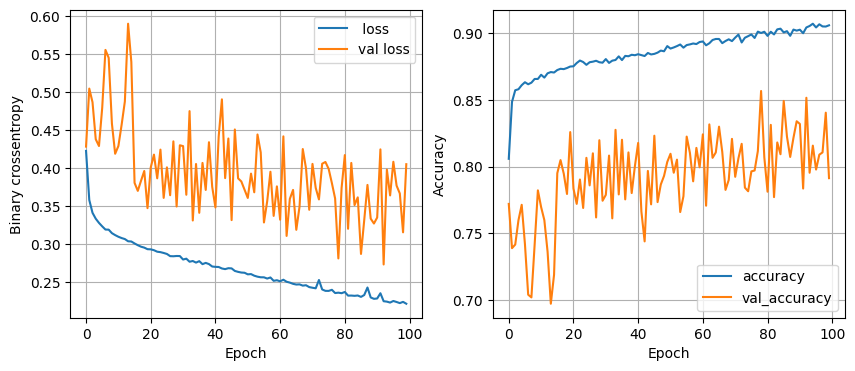

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8686 - loss: 0.3367
64 nodes ,dropout 0, lr 0.01,batch_size 64


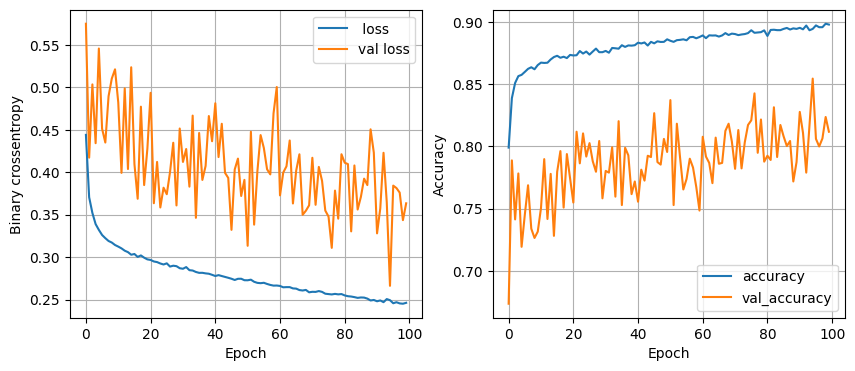

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8696 - loss: 0.3377
64 nodes ,dropout 0, lr 0.01,batch_size 128


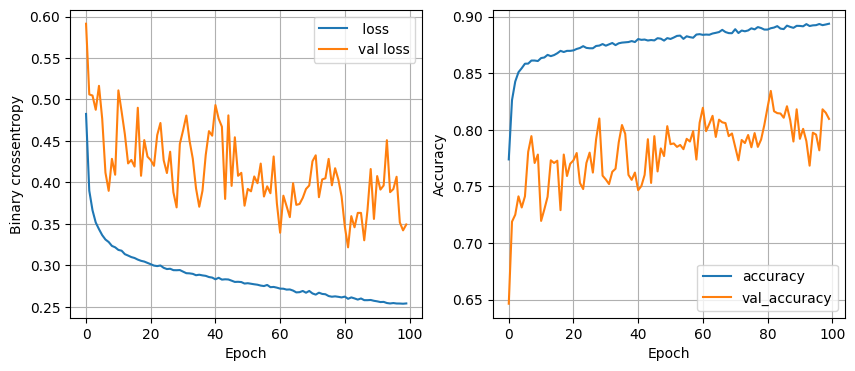

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step - accuracy: 0.8764 - loss: 0.3159
64 nodes ,dropout 0, lr 0.005,batch_size 32


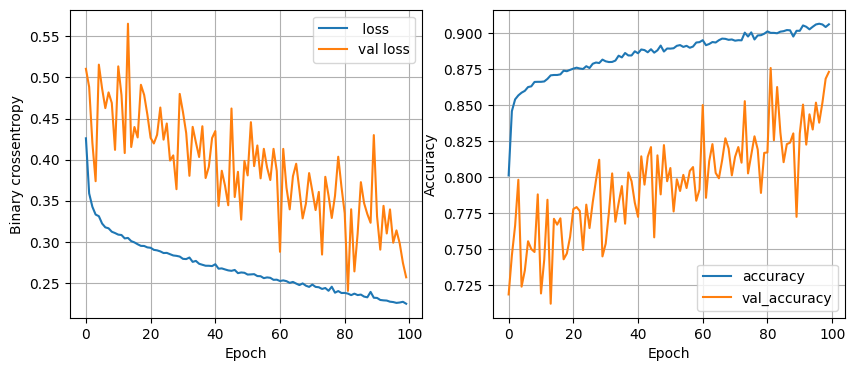

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8628 - loss: 0.3444
64 nodes ,dropout 0, lr 0.005,batch_size 64


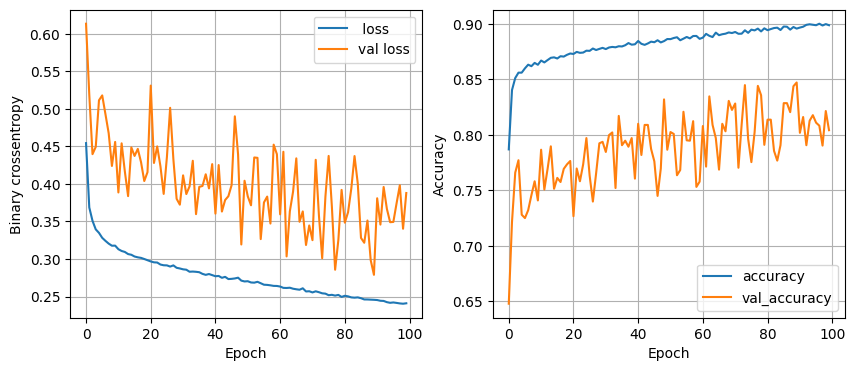

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step - accuracy: 0.8746 - loss: 0.3300
64 nodes ,dropout 0, lr 0.005,batch_size 128


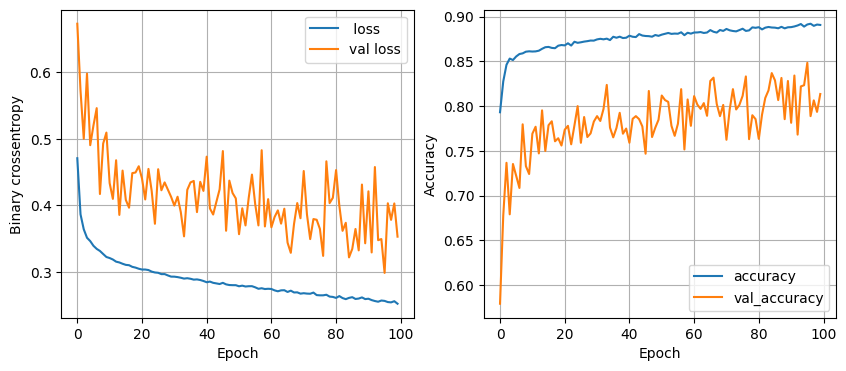

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8722 - loss: 0.3229
64 nodes ,dropout 0, lr 0.001,batch_size 32


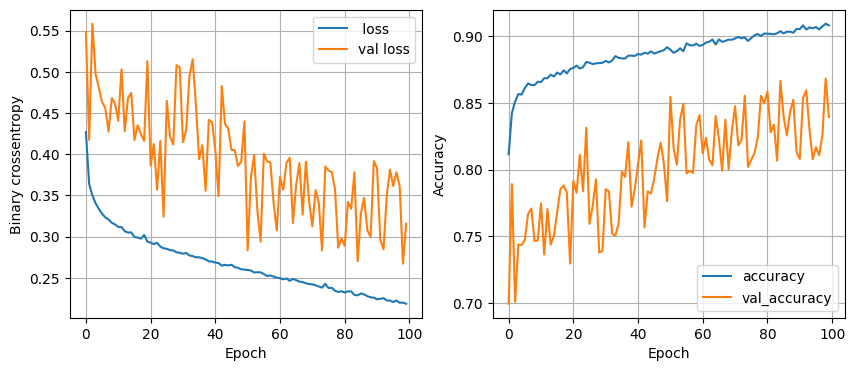

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 835us/step - accuracy: 0.8728 - loss: 0.3400
64 nodes ,dropout 0, lr 0.001,batch_size 64


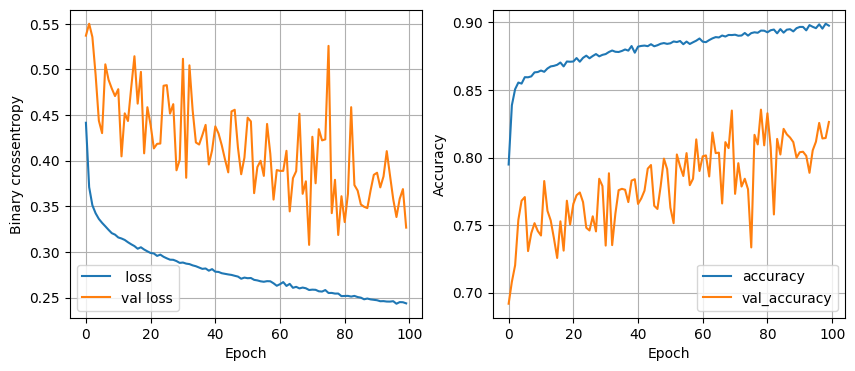

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 879us/step - accuracy: 0.8683 - loss: 0.3371
64 nodes ,dropout 0, lr 0.001,batch_size 128


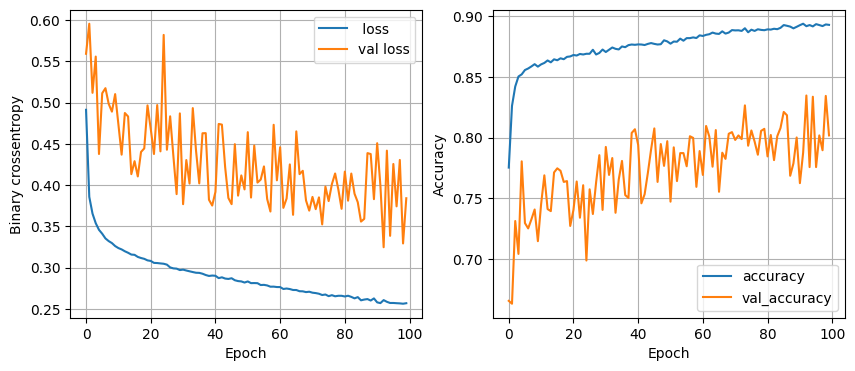

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8738 - loss: 0.3050
64 nodes ,dropout 0.2, lr 0.01,batch_size 32


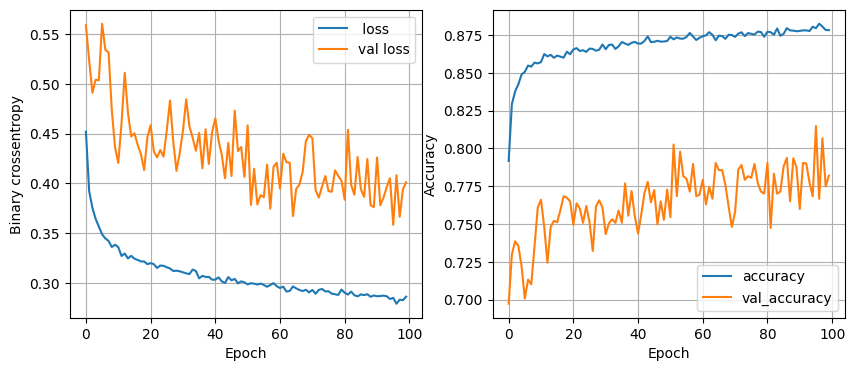

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 882us/step - accuracy: 0.8780 - loss: 0.2966
64 nodes ,dropout 0.2, lr 0.01,batch_size 64


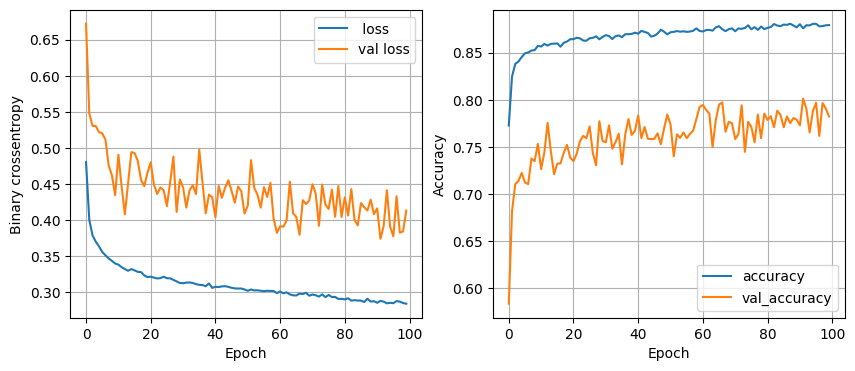

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 912us/step - accuracy: 0.8812 - loss: 0.2882
64 nodes ,dropout 0.2, lr 0.01,batch_size 128


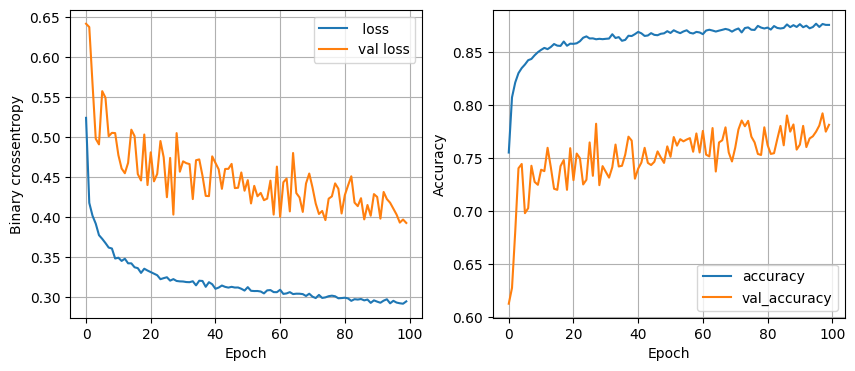

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8796 - loss: 0.2976
64 nodes ,dropout 0.2, lr 0.005,batch_size 32


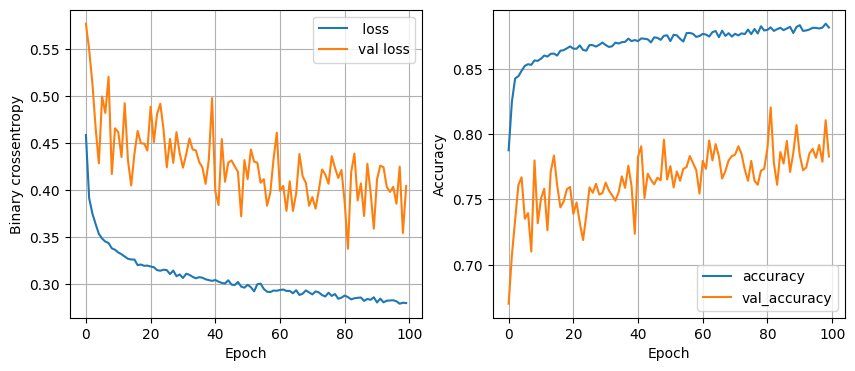

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 920us/step - accuracy: 0.8825 - loss: 0.2928
64 nodes ,dropout 0.2, lr 0.005,batch_size 64


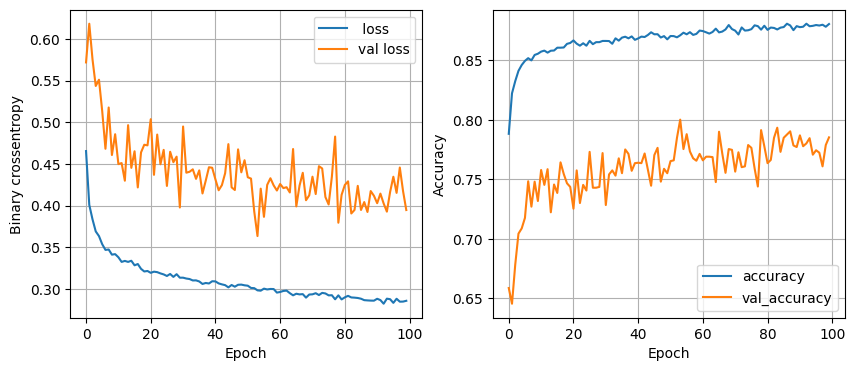

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 924us/step - accuracy: 0.8835 - loss: 0.2949
64 nodes ,dropout 0.2, lr 0.005,batch_size 128


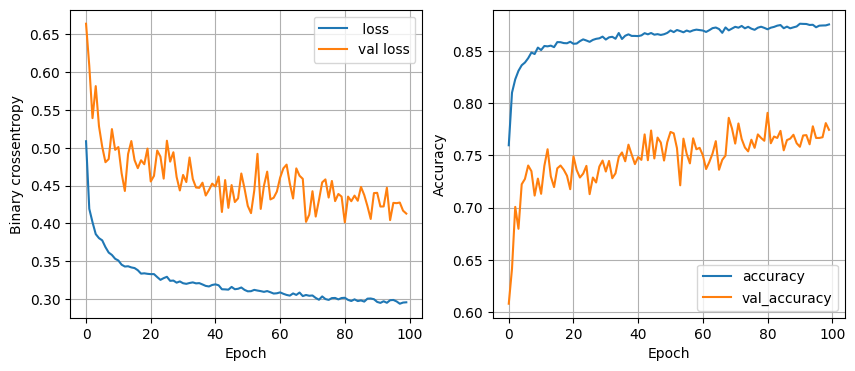

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 964us/step - accuracy: 0.8830 - loss: 0.2960
64 nodes ,dropout 0.2, lr 0.001,batch_size 32


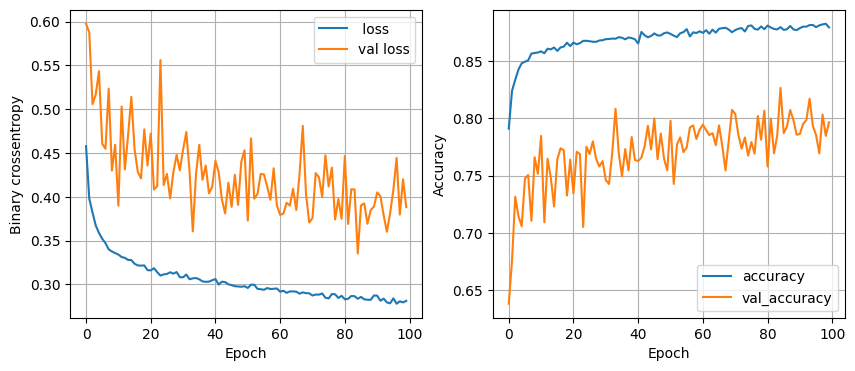

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 938us/step - accuracy: 0.8780 - loss: 0.2917
64 nodes ,dropout 0.2, lr 0.001,batch_size 64


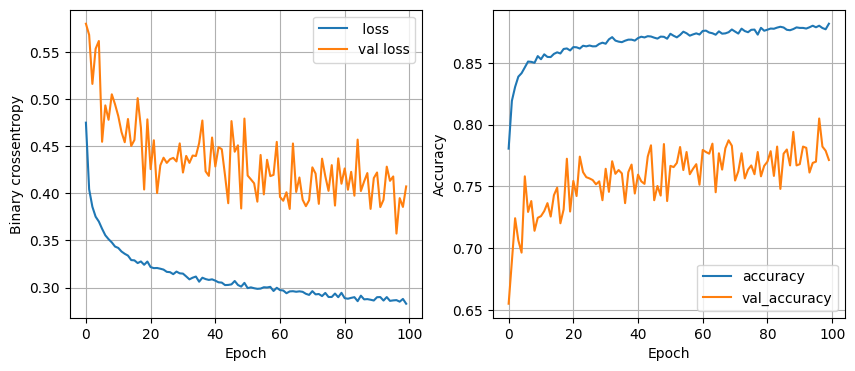

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 865us/step - accuracy: 0.8807 - loss: 0.2936
64 nodes ,dropout 0.2, lr 0.001,batch_size 128


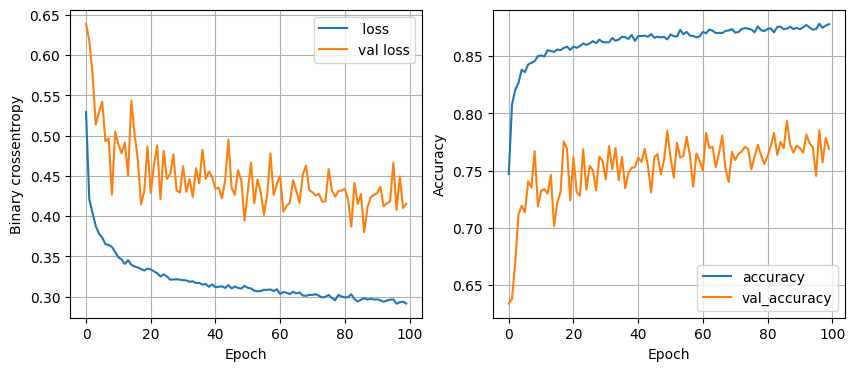

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 909us/step - accuracy: 0.8801 - loss: 0.2933


In [38]:
least_val_loss = float('inf')
least_val_model = None
epochs = 100
for num_nodes in [16,32,64]:
    for dropout_prob in [0,0.2]:
        for lr in [0.01,0.005,0.001]:
            for batch_size in [32,64,128]:
                print(f"{num_nodes} nodes ,dropout {dropout_prob}, lr {lr},batch_size {batch_size}")
                model , history = train_model(x_train,y_train,num_nodes,dropout_prob,lr,batch_size,epochs)
                plot_history(history)
                val_loss = model.evaluate(x_valid,y_valid)[0]
                if val_loss < least_val_loss:
                    least_val_loss = val_loss
                    least_val_model = model 

In [39]:
y_pred = least_val_model.predict(x_test)
y_pred = (y_pred > 0.5).astype(int).reshape(-1,)


119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [40]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.76      0.82      1346
           1       0.88      0.95      0.91      2458

    accuracy                           0.88      3804
   macro avg       0.88      0.85      0.86      3804
weighted avg       0.88      0.88      0.88      3804

